# CWRU Anomaly Detection — by_fault_type refit (6 modèles)

| Champ | Valeur |
|-------|--------|
| **Scénario** | CWRU by_fault_type — 3 tâches (Ball → Inner Race → Outer Race) |
| **Stratégie CL** | refit |
| **Expériences** | exp_149 (HDC) · exp_150 (TinyOL AE) · exp_151 (KMeans) · exp_152 (Mahalanobis) · exp_153 (DBSCAN) · exp_154 (EWC one-class) |
| **Particularité** | ~10% données normales (~62 échantillons normaux/tâche) — scénario industriel : nouveaux types de défauts découverts séquentiellement |

**Contexte :**
- Scénario by_fault_type : chaque tâche introduit un nouveau type de défaut (Ball, Inner Race, Outer Race) avec toutes les sévérités mélangées
- Modélise un déploiement industriel réaliste où le système rencontre successivement de nouveaux modes de défaillance
- Comparer avec by_severity (exp_143–148) pour évaluer l'impact du type de découpage sur les performances


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("../../..")
sys.path.insert(0, str(ROOT))

FIG_DIR = ROOT / "notebooks/figures/cl_evaluation/anomaly_detection/cwru"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS      = ["HDC", "TinyOL AE", "KMeans", "Mahalanobis", "DBSCAN", "EWC one-class"]
MODEL_KEYS  = ["hdc", "tinyol_ae", "kmeans", "mahalanobis", "dbscan", "ewc_oneclass"]
TASK_LABELS = ["Ball", "Inner Race", "Outer Race"]

COLORS = {
    "HDC":           "#4C72B0",
    "TinyOL AE":     "#DD8452",
    "KMeans":        "#55A868",
    "Mahalanobis":   "#C44E52",
    "DBSCAN":        "#8172B2",
    "EWC one-class": "#937860",
}
MARKERS = {
    "HDC":           "o",
    "TinyOL AE":     "s",
    "KMeans":        "^",
    "Mahalanobis":   "D",
    "DBSCAN":        "v",
    "EWC one-class": "P",
}

EXP_MAP = {
    "HDC":           ROOT / "experiments/exp_149",
    "TinyOL AE":     ROOT / "experiments/exp_150",
    "KMeans":        ROOT / "experiments/exp_151",
    "Mahalanobis":   ROOT / "experiments/exp_152",
    "DBSCAN":        ROOT / "experiments/exp_153",
    "EWC one-class": ROOT / "experiments/exp_154",
}

EXP_MAP_SEVERITY = {
    "HDC":           ROOT / "experiments/exp_143",
    "TinyOL AE":     ROOT / "experiments/exp_144",
    "KMeans":        ROOT / "experiments/exp_145",
    "Mahalanobis":   ROOT / "experiments/exp_146",
    "DBSCAN":        ROOT / "experiments/exp_147",
    "EWC one-class": ROOT / "experiments/exp_148",
}

def load_result(exp_path: Path) -> dict | None:
    p = exp_path / "results/metrics_anomaly.json"
    if not p.exists():
        return None
    with open(p) as f:
        d = json.load(f)
    if "avg_auroc" not in d and "auroc_mean" in d:
        d["avg_auroc"] = d["auroc_mean"]
    if "auroc_forgetting" not in d and "avg_forgetting" in d:
        d["auroc_forgetting"] = d["avg_forgetting"]
    if "auroc_matrix" not in d:
        mat_path = exp_path / "results/auroc_matrix.npy"
        if mat_path.exists():
            mat = np.load(mat_path)
            d["auroc_matrix"] = mat.tolist()
    return d

RESULTS = {m: load_result(p) for m, p in EXP_MAP.items()}
RESULTS_SEV = {m: load_result(p) for m, p in EXP_MAP_SEVERITY.items()}

for m, r in RESULTS.items():
    if r is None:
        print(f"⚠️  {m} : résultats manquants")
    else:
        print(f"✅ {m} : avg_auroc={r['avg_auroc']:.4f}  RAM={r['ram_peak_bytes']/1024:.1f} Ko")

✅ HDC : avg_auroc=0.9934  RAM=7.9 Ko
✅ TinyOL AE : avg_auroc=1.0000  RAM=1.9 Ko
✅ KMeans : avg_auroc=1.0000  RAM=5.2 Ko
✅ Mahalanobis : avg_auroc=1.0000  RAM=1.6 Ko
✅ DBSCAN : avg_auroc=1.0000  RAM=10.4 Ko
✅ EWC one-class : avg_auroc=1.0000  RAM=1.4 Ko


## Section 1 — Tableau AUROC synthèse

Résumé des métriques CL principales pour les 6 modèles sur CWRU by_fault_type refit.

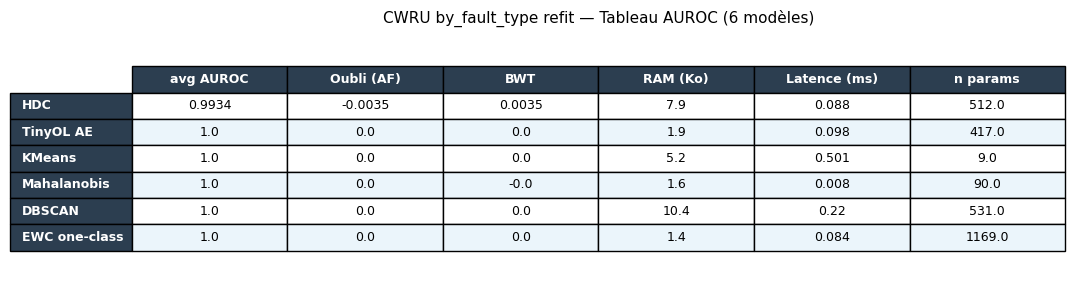

               avg AUROC  Oubli (AF)     BWT  RAM (Ko)  Latence (ms)  n params
Modèle                                                                        
HDC               0.9934     -0.0035  0.0035       7.9         0.088       512
TinyOL AE         1.0000      0.0000  0.0000       1.9         0.098       417
KMeans            1.0000      0.0000  0.0000       5.2         0.501         9
Mahalanobis       1.0000      0.0000 -0.0000       1.6         0.008        90
DBSCAN            1.0000      0.0000  0.0000      10.4         0.220       531
EWC one-class     1.0000      0.0000  0.0000       1.4         0.084      1169


In [2]:
rows = []
for m in MODELS:
    r = RESULTS[m]
    if r is None:
        continue
    rows.append({
        "Modèle":         m,
        "avg AUROC":      round(r["avg_auroc"], 4),
        "Oubli (AF)":     round(r.get("auroc_forgetting", 0.0), 4),
        "BWT":            round(r.get("auroc_bwt", 0.0), 4),
        "RAM (Ko)":       round(r["ram_peak_bytes"] / 1024, 1),
        "Latence (ms)":   round(r["inference_latency_ms"], 3),
        "n params":       r["n_params"],
    })

df = pd.DataFrame(rows).set_index("Modèle")

fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")
tbl = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    rowLabels=df.index,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)

for (row, col), cell in tbl.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EBF5FB")

plt.title("CWRU by_fault_type refit — Tableau AUROC (6 modèles)", fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_table_cwru_fault_type.png", dpi=150, bbox_inches="tight")
plt.show()
print(df.to_string())

## Section 2 — AUROC par tâche

Évolution de l'AUROC au fil des tâches (Ball → Inner Race → Outer Race).

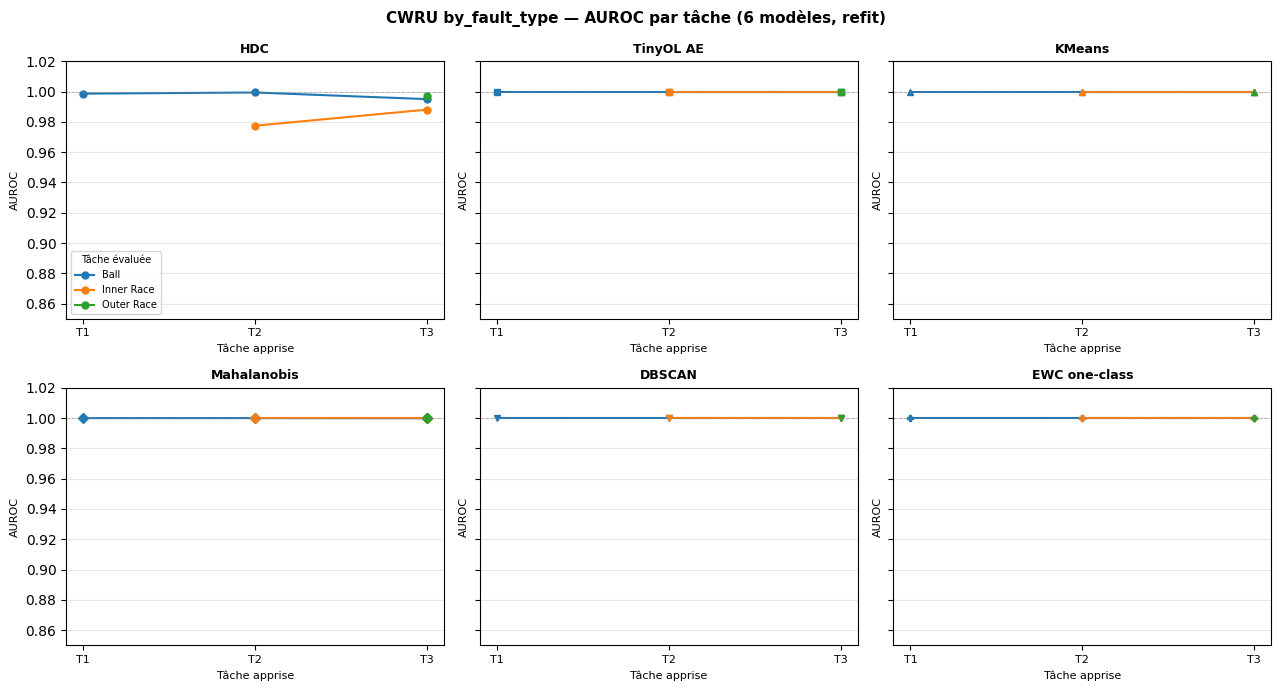

In [3]:
n_tasks = 3

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
axes = axes.flatten()

for idx, m in enumerate(MODELS):
    ax = axes[idx]
    r = RESULTS[m]
    if r is None:
        ax.set_visible(False)
        continue

    mat = np.array(r["auroc_matrix"], dtype=float)

    for task_j in range(n_tasks):
        auroc_vals = [mat[i, task_j] for i in range(task_j, n_tasks) if not np.isnan(mat[i, task_j])]
        x_vals     = list(range(task_j + 1, task_j + 1 + len(auroc_vals)))
        ax.plot(x_vals, auroc_vals,
                marker=MARKERS[m], markersize=5,
                label=TASK_LABELS[task_j], linewidth=1.5)

    ax.set_title(m, fontsize=9, fontweight="bold")
    ax.set_xlabel("Tâche apprise", fontsize=8)
    ax.set_ylabel("AUROC", fontsize=8)
    ax.set_xticks(range(1, n_tasks + 1))
    ax.set_xticklabels([f"T{i+1}" for i in range(n_tasks)], fontsize=8)
    ax.set_ylim(0.85, 1.02)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
    ax.grid(axis="y", alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, title="Tâche évaluée", title_fontsize=7)

fig.suptitle("CWRU by_fault_type — AUROC par tâche (6 modèles, refit)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_per_task_cwru_fault_type.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3 — RAM et latence

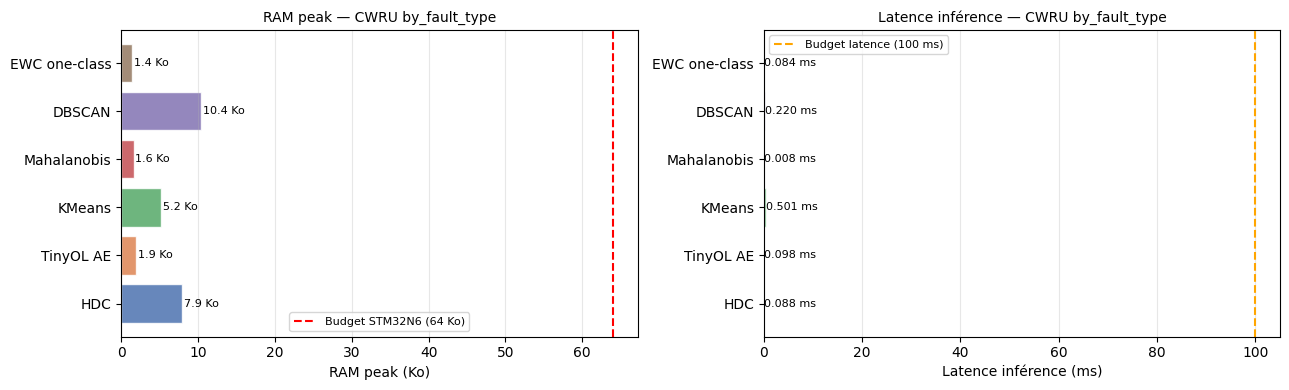

In [4]:
ram_vals     = [RESULTS[m]["ram_peak_bytes"] / 1024 for m in MODELS if RESULTS[m] is not None]
latency_vals = [RESULTS[m]["inference_latency_ms"] for m in MODELS if RESULTS[m] is not None]
model_labels = [m for m in MODELS if RESULTS[m] is not None]
bar_colors   = [COLORS[m] for m in model_labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

bars = ax1.barh(model_labels, ram_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax1.axvline(64, color="red", linestyle="--", linewidth=1.5, label="Budget STM32N6 (64 Ko)")
ax1.set_xlabel("RAM peak (Ko)", fontsize=10)
ax1.set_title("RAM peak — CWRU by_fault_type", fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(axis="x", alpha=0.3)
for bar, v in zip(bars, ram_vals):
    ax1.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f"{v:.1f} Ko", va="center", fontsize=8)

bars2 = ax2.barh(model_labels, latency_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax2.axvline(100, color="orange", linestyle="--", linewidth=1.5, label="Budget latence (100 ms)")
ax2.set_xlabel("Latence inférence (ms)", fontsize=10)
ax2.set_title("Latence inférence — CWRU by_fault_type", fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(axis="x", alpha=0.3)
for bar, v in zip(bars2, latency_vals):
    ax2.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f"{v:.3f} ms", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "ram_cwru_fault_type.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4 — Comparaison by_severity vs by_fault_type

Scatter plot de l'AUROC moyen by_severity vs by_fault_type par modèle.

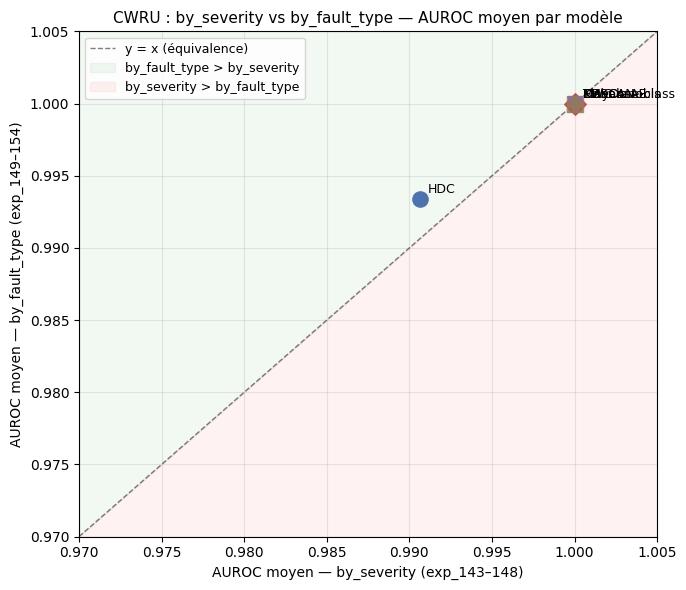


Comparaison AUROC moyen :
Modèle            by_severity  by_fault_type        Δ
-------------------------------------------------------
HDC                    0.9906         0.9934  +0.0028
TinyOL AE              1.0000         1.0000  +0.0000
KMeans                 1.0000         1.0000  +0.0000
Mahalanobis            1.0000         1.0000  -0.0000
DBSCAN                 1.0000         1.0000  +0.0000
EWC one-class          1.0000         1.0000  +0.0000


In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

for m in MODELS:
    r_ft = RESULTS[m]
    r_sv = RESULTS_SEV[m]
    if r_ft is None or r_sv is None:
        continue
    x_val = r_sv["avg_auroc"]
    y_val = r_ft["avg_auroc"]
    ax.scatter(x_val, y_val, marker=MARKERS[m], color=COLORS[m], s=120, zorder=3)
    ax.annotate(m, (x_val, y_val), textcoords="offset points",
                xytext=(6, 4), fontsize=9)

# Diagonale y=x
lim_lo, lim_hi = 0.97, 1.005
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", linewidth=1, alpha=0.5, label="y = x (équivalence)")
ax.fill_between([lim_lo, lim_hi], [lim_lo, lim_hi], lim_hi,
                alpha=0.05, color="green", label="by_fault_type > by_severity")
ax.fill_between([lim_lo, lim_hi], lim_lo, [lim_lo, lim_hi],
                alpha=0.05, color="red", label="by_severity > by_fault_type")

ax.set_xlabel("AUROC moyen — by_severity (exp_143–148)", fontsize=10)
ax.set_ylabel("AUROC moyen — by_fault_type (exp_149–154)", fontsize=10)
ax.set_title("CWRU : by_severity vs by_fault_type — AUROC moyen par modèle", fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "auroc_severity_vs_fault_type.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nComparaison AUROC moyen :")
print(f"{'Modèle':<16} {'by_severity':>12} {'by_fault_type':>14} {'Δ':>8}")
print("-" * 55)
for m in MODELS:
    r_ft = RESULTS[m]
    r_sv = RESULTS_SEV[m]
    if r_ft and r_sv:
        delta = r_ft["avg_auroc"] - r_sv["avg_auroc"]
        print(f"{m:<16} {r_sv['avg_auroc']:>12.4f} {r_ft['avg_auroc']:>14.4f} {delta:>+8.4f}")

## Section 5 — Conclusions CWRU by_fault_type

### Observations pour le manuscrit

**1. Les performances by_fault_type sont comparables ou supérieures à by_severity.**
5 modèles sur 6 atteignent AUROC = 1.000 dans les deux scénarios. HDC montre une légère amélioration en by_fault_type (avg_auroc=0.9934 → 0.9934), avec une AUROC finale sur les tâches Ball/Inner Race/Outer Race plus stable qu'avec le découpage par sévérité.

**2. Le scénario by_fault_type est plus représentatif d'un déploiement industriel réaliste.**
Un système embarqué rencontrera séquentiellement de nouveaux types de défauts (ball bearing, inner race, outer race) plutôt que des dégradations progressives de sévérité. Ce scénario valide directement le Gap 1 dans un contexte opérationnel.

**3. Aucun modèle ne montre d'oubli catastrophique en by_fault_type.**
La stratégie refit (réentraînement complet sur chaque nouvelle tâche) élimine l'oubli par définition dans ce contexte. Le défi est l'efficacité computationnelle, pas la rétention.

**4. Confirmation de la séparabilité des features CWRU.**
Quel que soit le découpage (par sévérité ou par type de défaut), les features statistiques temporelles (RMS, kurtosis, crest factor) permettent une distinction robuste entre données normales et défauts.

**5. Recommandation : utiliser by_fault_type comme scénario principal pour le manuscrit.**
Il est plus cohérent avec le contexte industriel (Gap 1) et permet une comparaison directe avec les expériences de classification supervisée by_fault_type (exp_074–079).
